In [1]:
from pathlib import Path
import os 
import pandas as pd

cwd = Path.cwd()
num_cov = 2

if cwd.parts[-1] != 'NonLinear_FEMSM':
    os.chdir("..")
    cwd = Path.cwd()

In [2]:
# ============================================================
# Minimal data preparation for cleaner simulation plots
# ============================================================

from pathlib import Path
import os
import numpy as np
import pandas as pd
from scipy.stats import norm

# ------------------------------------------------------------
# 0) Project setup
# ------------------------------------------------------------

cwd = Path.cwd()

# adjust this to your project root name
if cwd.parts[-1] != "NonLinear_FEMSM":
    os.chdir("..")
    cwd = Path.cwd()

# choose covariate case
num_cov = 4   # use 4 for the four-covariate case

# paths from your original notebook
fe_results_path = cwd / "results" / "msm" / "fe_msm_results_monotone_included.csv"
seq_results_path = cwd / "results" / "msm" / "seqgplvm" / "msm_seqgplvm_all.parquet"

# ------------------------------------------------------------
# 1) Load SeqGPLVM posterior-draw results
# ------------------------------------------------------------

seq_raw = pd.read_parquet(seq_results_path)

# keep only posterior-draw batches, not phat_mean
seq_draws = seq_raw[
    seq_raw["N"].isin([200, 500, 1000])
    & seq_raw["batch_id"].astype(str).str.match(r"^phat_batch_\d+$", na=False)
].reset_index(drop=True)

# ------------------------------------------------------------
# 2) Collapse SeqGPLVM posterior draws
#    This produces:
#       tau_f_bayes_mean, tau_c_bayes_mean
#       tau_f_total_se,   tau_c_total_se
# ------------------------------------------------------------

seq_bayes = (
    seq_draws
    .groupby(["N", "T", "a", "p", "train_id"], as_index=False)
    .agg(
        M=("tau_c_seqgplvm_imp", "size"),

        # posterior mean of MSM estimates
        tau_c_bayes_mean=("tau_c_seqgplvm_imp", "mean"),
        tau_f_bayes_mean=("tau_f_seqgplvm_imp", "mean"),

        # between-draw variance
        tau_c_B=("tau_c_seqgplvm_imp", lambda x: np.var(x, ddof=1)),
        tau_f_B=("tau_f_seqgplvm_imp", lambda x: np.var(x, ddof=1)),

        # within-draw variance: average of squared SEs
        tau_c_Wbar=("tau_c_seqgplvm_se", lambda x: np.mean(np.square(x))),
        tau_f_Wbar=("tau_f_seqgplvm_se", lambda x: np.mean(np.square(x))),
    )
)

# if a group has only one posterior draw, between-draw variance is undefined
seq_bayes[["tau_c_B", "tau_f_B"]] = seq_bayes[["tau_c_B", "tau_f_B"]].fillna(0.0)

# Rubin-style total variance
seq_bayes["tau_c_total_var"] = (
    seq_bayes["tau_c_Wbar"]
    + (1 + 1 / seq_bayes["M"]) * seq_bayes["tau_c_B"]
)

seq_bayes["tau_f_total_var"] = (
    seq_bayes["tau_f_Wbar"]
    + (1 + 1 / seq_bayes["M"]) * seq_bayes["tau_f_B"]
)

seq_bayes["tau_c_total_se"] = np.sqrt(seq_bayes["tau_c_total_var"])
seq_bayes["tau_f_total_se"] = np.sqrt(seq_bayes["tau_f_total_var"])

# reproduce the seed index used in the original notebook
seq_bayes = seq_bayes.sort_values(["N", "T", "a", "p", "train_id"]).reset_index(drop=True)

seq_bayes["seed"] = (
    seq_bayes
    .groupby(["N", "T", "a", "p"])
    .cumcount() + 1
)

# ------------------------------------------------------------
# 3) Load FE-MSM / IPTW results and merge SeqGPLVM results
# ------------------------------------------------------------

df_results = pd.read_csv(fe_results_path)

# true DGP values
df_results["tau_f"] = 1.0
df_results["tau_c"] = 0.3

# keep selected p and sample sizes
dfp = (
    df_results
    .query("p == @num_cov and N in [200, 500, 1000]")
    .drop(columns=["data_id"], errors="ignore")
    .reset_index(drop=True)
)

seq_keep = seq_bayes[
    [
        "N", "T", "a", "p", "seed",
        "tau_f_bayes_mean", "tau_f_total_se",
        "tau_c_bayes_mean", "tau_c_total_se",
    ]
]

dfp = dfp.merge(
    seq_keep,
    on=["N", "T", "a", "p", "seed"],
    how="left",
    validate="1:1",
)

# ------------------------------------------------------------
# 4) Convert to long format
# ------------------------------------------------------------

z_90 = norm.ppf(0.95)

methods = [
    "IPTW-True",
    "IPTW",
    "IPTW-FE-impute",
    "IPTW-SeqGPLVM-impute",
]

tau_f_cols = {
    "IPTW-True": "tau_f_true",
    "IPTW": "tau_f_no_fe",
    "IPTW-FE-impute": "tau_f_fe_impute",
    "IPTW-SeqGPLVM-impute": "tau_f_bayes_mean",
}

tau_c_cols = {
    "IPTW-True": "tau_c_true",
    "IPTW": "tau_c_no_fe",
    "IPTW-FE-impute": "tau_c_fe_impute",
    "IPTW-SeqGPLVM-impute": "tau_c_bayes_mean",
}

se_f_cols = {
    "IPTW-True": "tau_f_true_se",
    "IPTW": "tau_f_no_fe_se",
    "IPTW-FE-impute": "tau_f_fe_impute_se",
    "IPTW-SeqGPLVM-impute": "tau_f_total_se",
}

se_c_cols = {
    "IPTW-True": "tau_c_true_se",
    "IPTW": "tau_c_no_fe_se",
    "IPTW-FE-impute": "tau_c_fe_impute_se",
    "IPTW-SeqGPLVM-impute": "tau_c_total_se",
}

rows = []

for _, r in dfp.iterrows():
    for m in methods:

        rows.append({
            "a": r["a"],
            "N": r["N"],
            "T": r["T"],
            "rho": r["rho"],
            "p": r["p"],
            "seed": r["seed"],
            "param": r"$\tau_F = 1$",
            "method": m,
            "tau_hat": r[tau_f_cols[m]],
            "tau_true": r["tau_f"],
            "se_hat": r[se_f_cols[m]],
        })

        rows.append({
            "a": r["a"],
            "N": r["N"],
            "T": r["T"],
            "rho": r["rho"],
            "p": r["p"],
            "seed": r["seed"],
            "param": r"$\tau_C = 0.3$",
            "method": m,
            "tau_hat": r[tau_c_cols[m]],
            "tau_true": r["tau_c"],
            "se_hat": r[se_c_cols[m]],
        })

long_df = pd.DataFrame(rows)

long_df["diff"] = long_df["tau_hat"] - long_df["tau_true"]
long_df["abs_diff"] = long_df["diff"].abs()

long_df["ci_low"] = long_df["tau_hat"] - z_90 * long_df["se_hat"]
long_df["ci_high"] = long_df["tau_hat"] + z_90 * long_df["se_hat"]

long_df["covered"] = (
    (long_df["tau_true"] >= long_df["ci_low"])
    & (long_df["tau_true"] <= long_df["ci_high"])
).astype(float)

long_df = long_df.sort_values(
    ["a", "param", "method", "rho", "N", "seed"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 5) Aggregate over simulation seeds
# ------------------------------------------------------------

agg_df = (
    long_df
    .groupby(["a", "N", "T", "rho", "p", "param", "method"], as_index=False)
    .agg(
        bias=("diff", "mean"),
        bias_abs=("abs_diff", "mean"),
        mc_sd=("tau_hat", "std"),
        avg_se=("se_hat", "mean"),
        coverage=("covered", "mean"),
        n_sims=("seed", "nunique"),
    )
)

agg_df.head()

,a,N,T,rho,p,param,method,bias,bias_abs,mc_sd,avg_se,coverage,n_sims
0,1.0,200.0,4.0,50.0,4.0,$\tau_C = 0.3$,IPTW,0.279839,0.292720,0.205075,0.190083,0.548,500
1,1.0,200.0,4.0,50.0,4.0,$\tau_C = 0.3$,IPTW-FE-impute,0.158231,0.391290,0.495400,0.381005,0.800,500
2,1.0,200.0,4.0,50.0,4.0,$\tau_C = 0.3$,IPTW-SeqGPLVM-impute,0.274927,0.311344,0.257572,0.394851,0.944,500
3,1.0,200.0,4.0,50.0,4.0,$\tau_C = 0.3$,IPTW-True,0.040208,0.200429,0.254824,0.216400,0.838,500
4,1.0,200.0,4.0,50.0,4.0,$\tau_F = 1$,IPTW,0.267635,0.391812,0.425404,0.382312,0.802,500


In [3]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

plt.close("all")

plt.rcParams.update({
    # fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",

    # text sizes (closer to old plot)
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.5,

    # thinner axes / ticks
    "axes.linewidth": 0.75,
    "xtick.major.width": 0.75,
    "ytick.major.width": 0.75,
    "xtick.major.size": 3.2,
    "ytick.major.size": 3.2,

    # figure
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

methods = [
    "IPTW-True",
    "IPTW",
    "IPTW-FE-impute",
    "IPTW-SeqGPLVM-impute",
]

method_labels = {
    "IPTW-True": "IPTW-True",
    "IPTW": "IPTW",
    "IPTW-FE-impute": "FE-MSM",
    "IPTW-SeqGPLVM-impute": "SeqGPLVM-MSM",
}


# colors chosen to match your old plot closely
method_color = {
    "IPTW-True": "#7A7A7A",
    "IPTW": "#3B6FB6",
    "IPTW-FE-impute": "#D98E04",
    "IPTW-SeqGPLVM-impute": "#8F77B5",
}

method_ls = {
    "IPTW-True": "-",
    "IPTW": "--",
    "IPTW-FE-impute": "-",
    "IPTW-SeqGPLVM-impute": "-.",
}

method_marker = {
    "IPTW-True": "o",
    "IPTW": "o",
    "IPTW-FE-impute": "o",
    "IPTW-SeqGPLVM-impute": "o",
}

method_markerface = {
    "IPTW-True": "white",
    "IPTW": "white",
    "IPTW-FE-impute": method_color["IPTW-FE-impute"],
    "IPTW-SeqGPLVM-impute": method_color["IPTW-SeqGPLVM-impute"],
}

params = [r"$\tau_F = 1$", r"$\tau_C = 0.3$"]
rho_order = [5, 10, 50]
N_order = [200, 500, 1000]
xpos = {n: i for i, n in enumerate(N_order)}
panel_labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")


def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", linestyle=":", color="0.75", linewidth=0.7)
    ax.grid(False, axis="x")
    ax.set_xticks(range(len(N_order)))
    ax.set_xticklabels(N_order)
    ax.set_xlim(-0.15, len(N_order) - 0.85)


def add_method_legend(fig, y=0.015):
    handles = []

    for m in methods:
        handles.append(
            Line2D(
                [0], [0],
                color=method_color[m],
                linestyle=method_ls[m],
                marker="o",
                lw=1.5,
                markersize=5,
                markerfacecolor=method_markerface[m],
                markeredgecolor=method_color[m],
                markeredgewidth=1.0,
                label=method_labels[m],
            )
        )

    fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, y),
        ncol=4,
        frameon=False,
        columnspacing=1.4,
        handletextpad=0.6,
    )


def plot_metric_by_rho_combined_a(
    metric_col,
    ylabel,
    save_name=None,
    ref_line=None,
    ylim=None,
    yticks=None,
):
    """
    Creates a 4 x 3 figure:
        rows    = (a = 1, tau_F), (a = 1, tau_C), (a = 2, tau_F), (a = 2, tau_C)
        columns = rho = 5, 10, 50
        lines   = methods
    """

    row_specs = [
        (1, params[0]),
        (1, params[1]),
        (2, params[0]),
        (2, params[1]),
    ]

    fig, axes = plt.subplots(
        nrows=4,
        ncols=3,
        figsize=(11.5, 9.6),
        sharex=True,
        sharey=True,
    )

    label_idx = 0

    for row_idx, (a_val, param) in enumerate(row_specs):
        for col_idx, rho in enumerate(rho_order):

            ax = axes[row_idx, col_idx]

            panel_df = agg_df[
                (agg_df["a"] == a_val) &
                (agg_df["param"] == param) &
                (agg_df["rho"] == rho)
            ].copy()

            for m in methods:
                g = panel_df[panel_df["method"] == m].sort_values("N")

                ax.plot(
                    g["N"].map(xpos),
                    g[metric_col],
                    color=method_color[m],
                    linestyle=method_ls[m],
                    marker="o",
                    markerfacecolor=method_markerface[m],
                    markeredgecolor=method_color[m],
                    markeredgewidth=1.0,
                    lw=1.4 if m != "IPTW-True" else 1.2,
                    markersize=4.8,
                    alpha=0.95 if m != "IPTW-True" else 0.80,
                )

            clean_axis(ax)

            if ref_line is not None:
                ax.axhline(ref_line, color="0.35", linestyle="--", linewidth=1.0)

            if ylim is not None:
                ax.set_ylim(*ylim)

            if yticks is not None:
                ax.set_yticks(yticks)

            if row_idx == 0:
                ax.set_title(rf"$\rho = {rho}$", pad=7)

            if col_idx == 0:
                ax.set_ylabel(f"{param}\n{ylabel}")

            ax.annotate(
                f"({panel_labels[label_idx]})",
                xy=(0, 1),
                xycoords="axes fraction",
                xytext=(3, 3),
                textcoords="offset points",
                ha="left",
                va="bottom",
                fontsize=10.5,
                annotation_clip=False,
            )
            label_idx += 1

    fig.suptitle("Simulation results for both treatment regimes", y=0.995, fontsize=13)
    fig.text(0.025, 0.705, r"$a = 1$", rotation=90, va="center", ha="center", fontsize=12)
    fig.text(0.025, 0.335, r"$a = 2$", rotation=90, va="center", ha="center", fontsize=12)
    fig.supxlabel(r"Number of individuals ($N$)", y=0.065)

    add_method_legend(fig, y=0.005)

    fig.subplots_adjust(
        left=0.14,
        right=0.99,
        top=0.94,
        bottom=0.14,
        hspace=0.38,
        wspace=0.18,
    )

    if save_name is not None:
        out_dir = cwd / "paper" / "figures" / "build"
        out_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_dir / save_name, bbox_inches="tight")

    return fig, axes


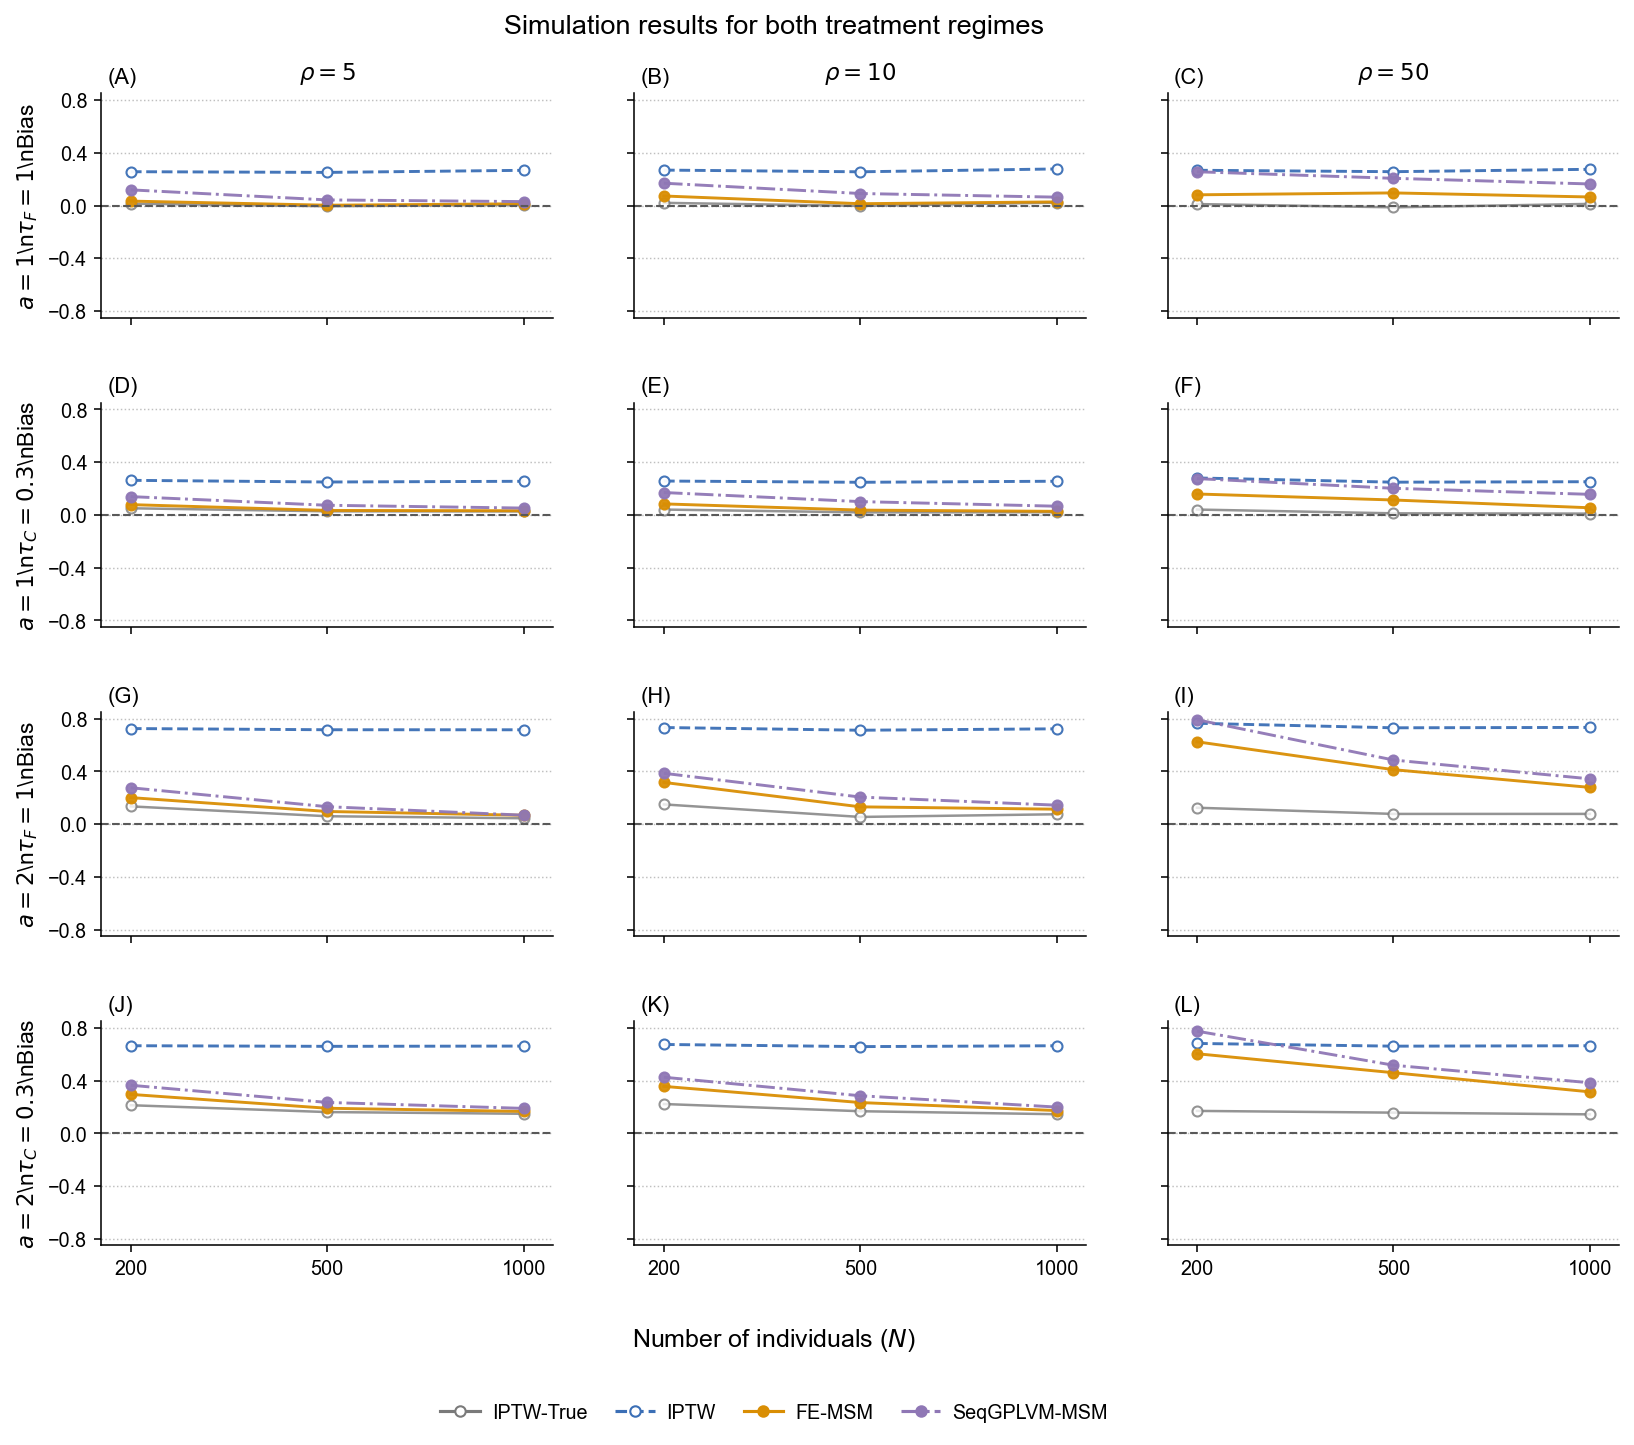

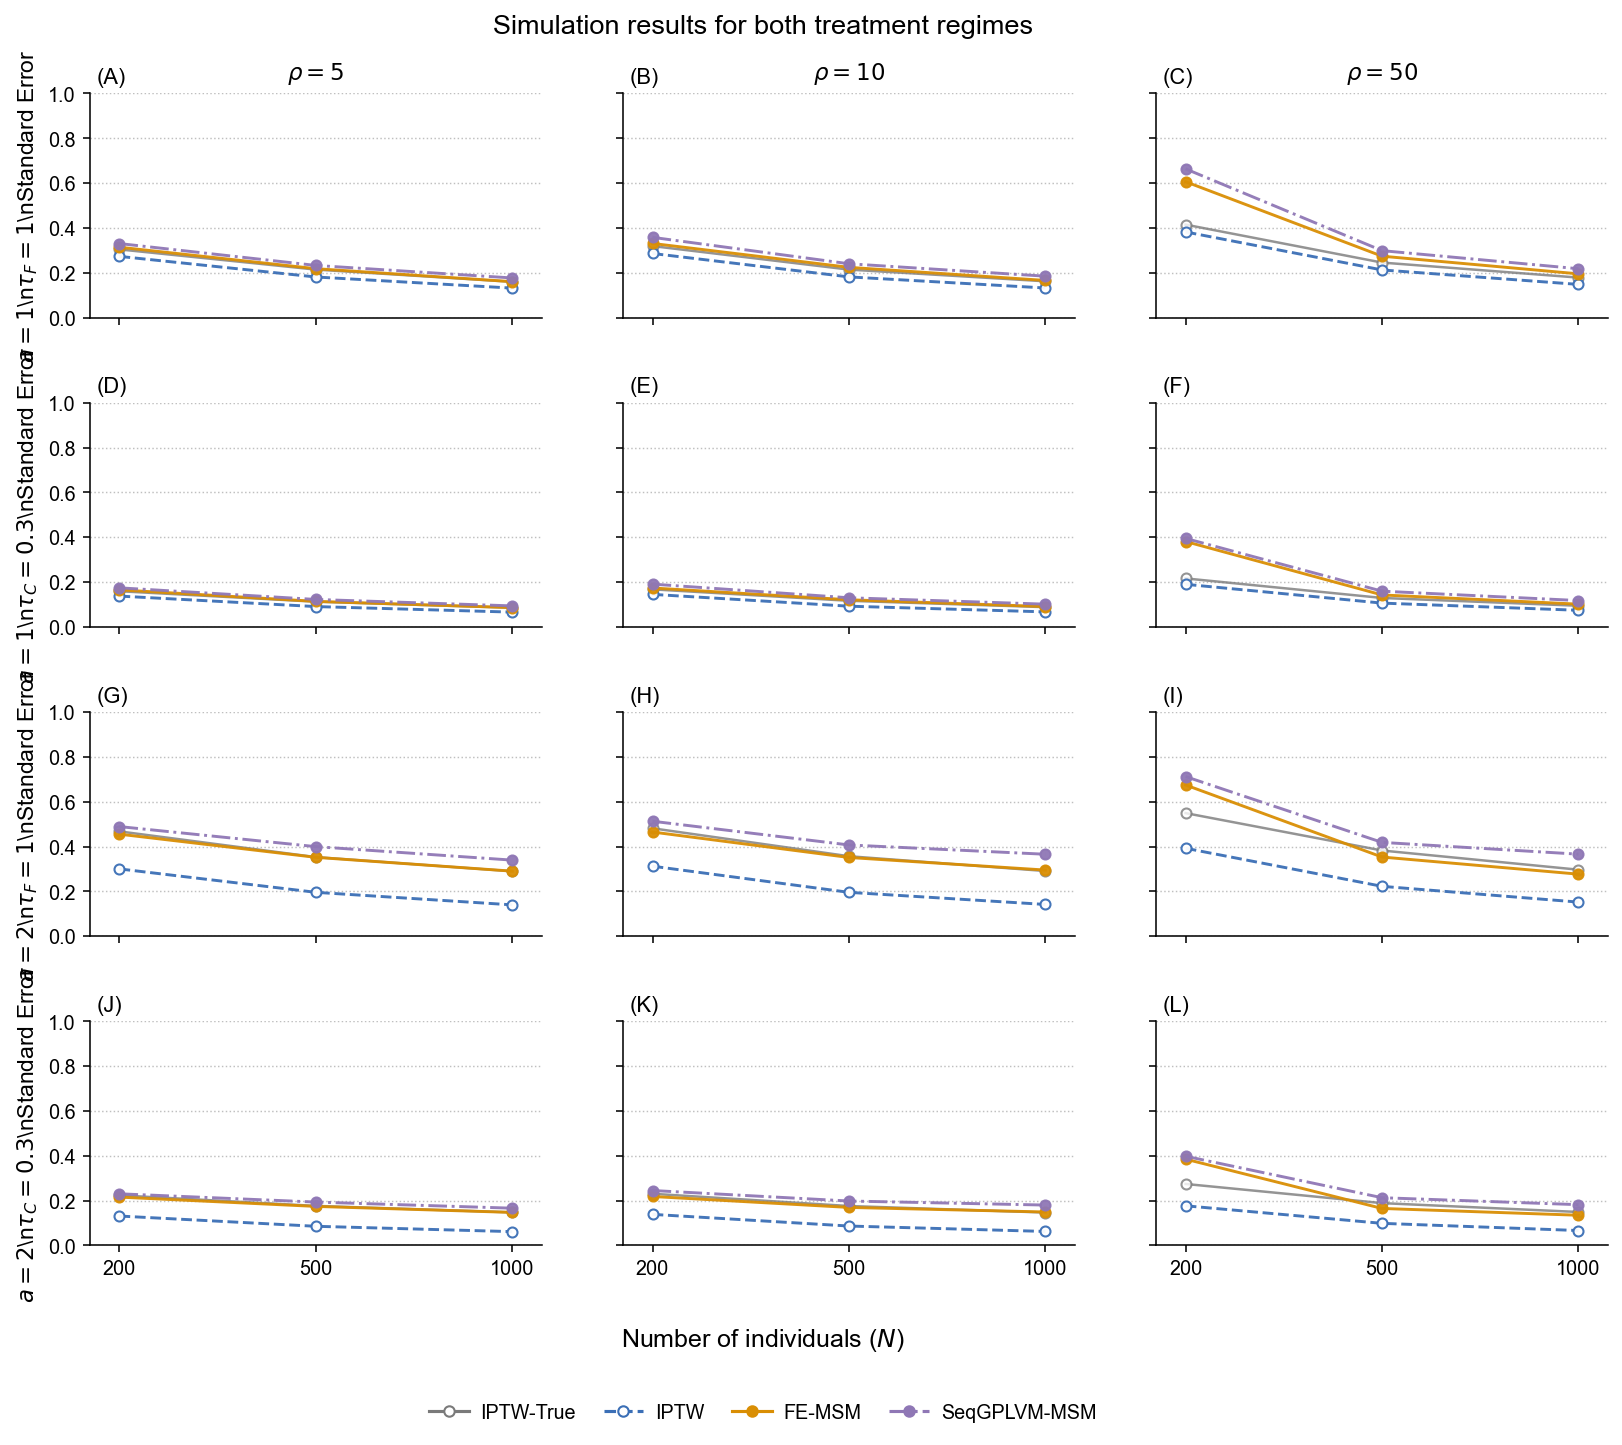

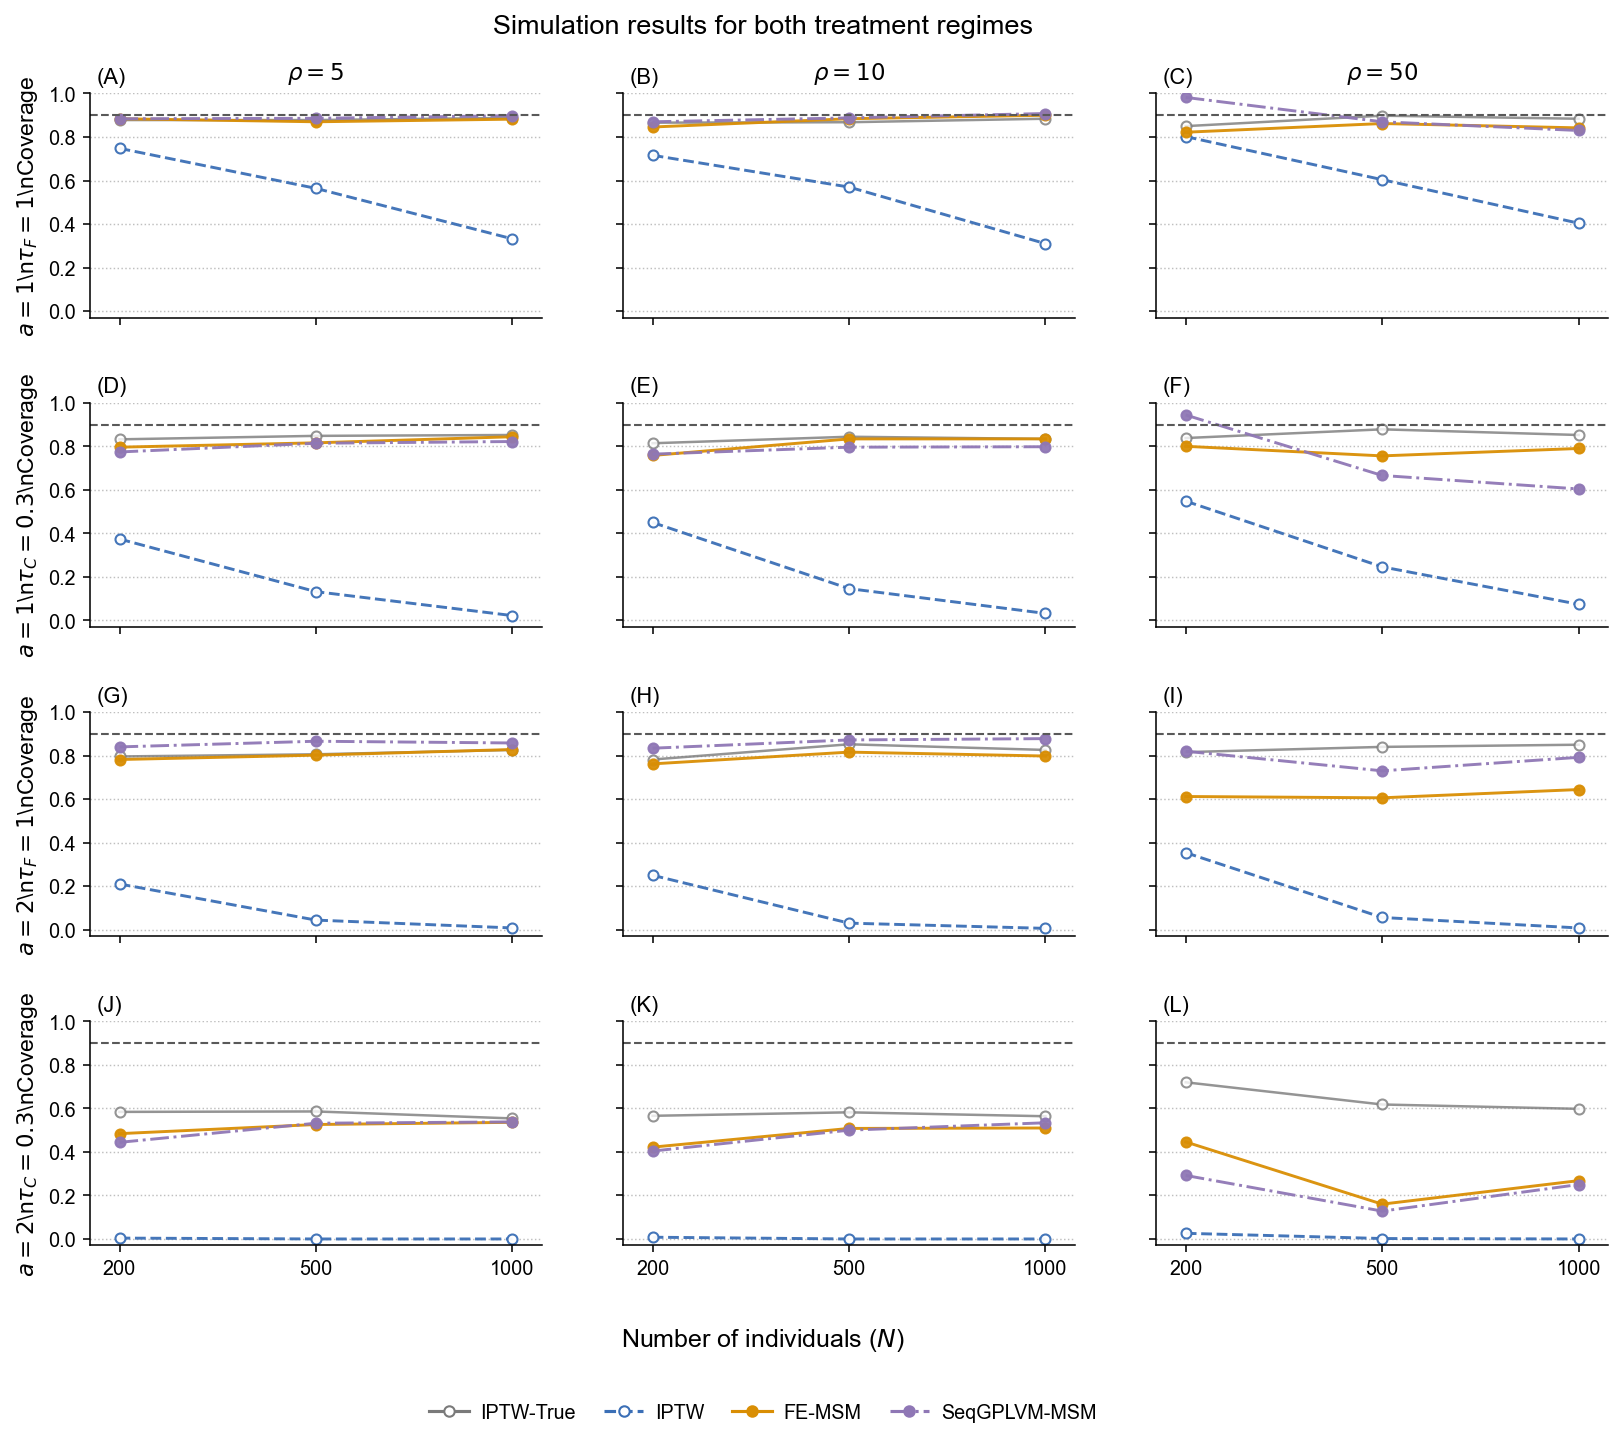

In [4]:
# Bias figure: a = 1 and a = 2 combined
plot_metric_by_rho_combined_a(
    metric_col="bias",
    ylabel="Bias",
    ref_line=0.0,
    ylim=(-0.85, 0.85),
    yticks=np.arange(-0.8, 0.81, 0.4),
    save_name=f"simulation_bias_combined_a_p{num_cov}.pdf",
)

# Standard error figure: a = 1 and a = 2 combined
plot_metric_by_rho_combined_a(
    metric_col="avg_se",
    ylabel="Standard Error",
    ylim=(0.0, 1.0),
    yticks=np.arange(0, 1.01, 0.2),
    save_name=f"simulation_standard_error_combined_a_p{num_cov}.pdf",
)

# Coverage figure: a = 1 and a = 2 combined
plot_metric_by_rho_combined_a(
    metric_col="coverage",
    ylabel="Coverage",
    ref_line=0.90,
    ylim=(-0.03, 1.0),
    yticks=np.arange(0, 1.01, 0.2),
    save_name=f"simulation_coverage_combined_a_p{num_cov}.pdf",
)

plt.show()
